# IMPORTING INDEPENDENCIES:

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
pd.options.display.float_format = '{:.2f}'.format
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import precision_recall_curve
from sklearn.linear_model import LogisticRegression
import warnings
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler,StandardScaler
warnings.filterwarnings('ignore')

# LOADING DATASET:

In [4]:
from pathlib import Path
data_path = Path(r"C:\Users\Hi\Desktop\Risk-Analysis\data\raw\healthcare_patient_readmission.csv")

data = pd.read_csv(data_path)
data.head()

,Patient_ID,Age,Gender,Region,Insurance_Type,Admission_Type,Hospital_Department,Length_of_Stay,Previous_Admissions,Previous_ER_Visits,...,Medication_Count,Lab_Test_Count,Average_Glucose,Systolic_BP,Discharge_Type,Followup_Scheduled,Followup_Attended,Treatment_Cost,Satisfaction_Score,Readmitted_30_Days
0,P100174,70.00,Male,Rift Valley,Employer,Emergency,Diabetes Care,9,4,0,...,6,15,191.60,115,Other,Yes,Yes,131330.00,3.90,No
1,P100275,48.00,Male,Rift Valley,NHIF,Elective,General Medicine,2,0,1,...,8,16,89.90,130,Home with Follow-up,No,No,48495.00,4.80,No
2,P100491,86.00,Male,Nairobi,NHIF,Emergency,Cardiology,3,2,3,...,2,5,129.00,132,Home,No,No,95824.00,3.20,No
3,P100073,51.00,Male,Rift Valley,NHIF,Elective,Orthopedics,6,2,1,...,4,12,126.50,136,Home,Yes,Yes,65729.00,3.60,No
4,P100306,28.00,Male,Central,Cash,Elective,Pediatrics,2,1,3,...,5,5,94.90,109,Home with Follow-up,Yes,No,49791.00,4.60,No


In [5]:
# Determining the number of rows and columns in the dataset

data.shape

(505, 23)

In [6]:
# Determining the number of rows and columns in the dataset

data.shape

(505, 23)

In [7]:
# Examining the data types of each column in the dataset
data.dtypes

Patient_ID                 str
Age                    float64
Gender                     str
Region                     str
Insurance_Type             str
Admission_Type             str
Hospital_Department        str
Length_of_Stay           int64
Previous_Admissions      int64
Previous_ER_Visits       int64
Diabetes                   str
Hypertension               str
Heart_Disease              str
Medication_Count         int64
Lab_Test_Count           int64
Average_Glucose        float64
Systolic_BP              int64
Discharge_Type             str
Followup_Scheduled         str
Followup_Attended          str
Treatment_Cost         float64
Satisfaction_Score     float64
Readmitted_30_Days         str
dtype: object

In [8]:
# Generating descriptive statistics for the dataset
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,495.00,54.12,20.99,18.00,37.00,54.00,73.00,90.00
Length_of_Stay,505.00,4.68,4.24,1.00,2.00,4.00,6.00,60.00
Previous_Admissions,505.00,1.12,1.03,0.00,0.00,1.00,2.00,5.00
Previous_ER_Visits,505.00,1.44,1.17,0.00,1.00,1.00,2.00,6.00
Medication_Count,505.00,5.87,2.44,0.00,4.00,6.00,7.00,14.00
Lab_Test_Count,505.00,9.06,3.27,1.00,7.00,9.00,11.00,21.00
Average_Glucose,493.00,123.31,32.70,55.00,99.70,121.60,144.60,212.10
Systolic_BP,505.00,130.40,18.62,85.00,117.00,130.00,143.00,191.00
Treatment_Cost,505.00,85868.84,32249.06,17712.00,62720.00,81476.00,104372.00,193348.00
Satisfaction_Score,495.00,3.82,0.77,0.00,3.30,3.80,4.30,7.00


In [9]:
# Identifying categorical and numerical columns in the dataset
categorical_columns = data.select_dtypes(include=['str']).columns
numerical_columns = data.select_dtypes(exclude=['str']).columns

print('Categorical Features :', ', '.join(categorical_columns))
print('Numerical Features :', ', '.join(numerical_columns))

Categorical Features : Patient_ID, Gender, Region, Insurance_Type, Admission_Type, Hospital_Department, Diabetes, Hypertension, Heart_Disease, Discharge_Type, Followup_Scheduled, Followup_Attended, Readmitted_30_Days
Numerical Features : Age, Length_of_Stay, Previous_Admissions, Previous_ER_Visits, Medication_Count, Lab_Test_Count, Average_Glucose, Systolic_BP, Treatment_Cost, Satisfaction_Score


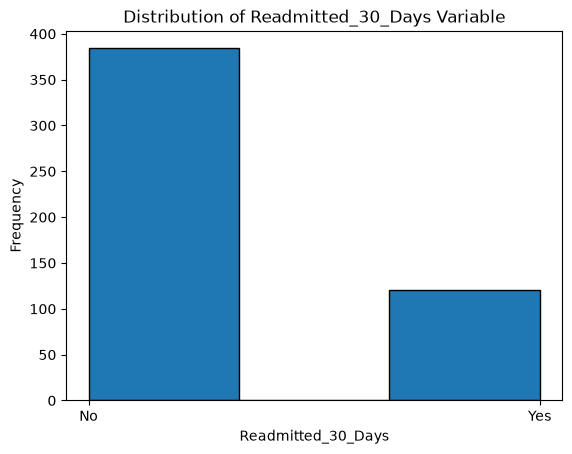

In [5]:
# Examining distribution of the target variable 'Readmitted_30_Days' in the dataset
import matplotlib.pyplot as plt

plt.hist(data['Readmitted_30_Days'], bins=3, edgecolor='black')
plt.xlabel('Readmitted_30_Days')
plt.ylabel('Frequency')
plt.title('Distribution of Readmitted_30_Days Variable')
#plt.show()

# save to reports   
plt.savefig('C:\\Users\\Hi\\Desktop\\Risk-Analysis\\reports\\distribution_readmitted_30_days.png')
plt.show()